# Libraries

In [31]:
import numpy as np
import mudata as md
import scanpy as sc
import anndata as ad
import matplotlib.pyplot as plt
import pandas as pd
import re

The totalVI way seems to require the model object. Not sure how to implement this here or if we should use a different method? 

# Read Files

In [2]:
mdata = md.read_h5mu("../../data/tonsil/tonsil_embedded.h5mu")
rna_adata = mdata.mod['RNA']
prot_adata = mdata.mod['Protein']

/opt/anaconda3/lib/python3.13/site-packages/mudata/_core/mudata.py:1598: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/opt/anaconda3/lib/python3.13/site-packages/mudata/_core/mudata.py:1461: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


In [5]:
# Normalizing to median total counts
sc.pp.normalize_total(rna_adata)
# Logarithmize the data
sc.pp.log1p(rna_adata)

# Wilcoxon Rank-Sum approach

## RNA

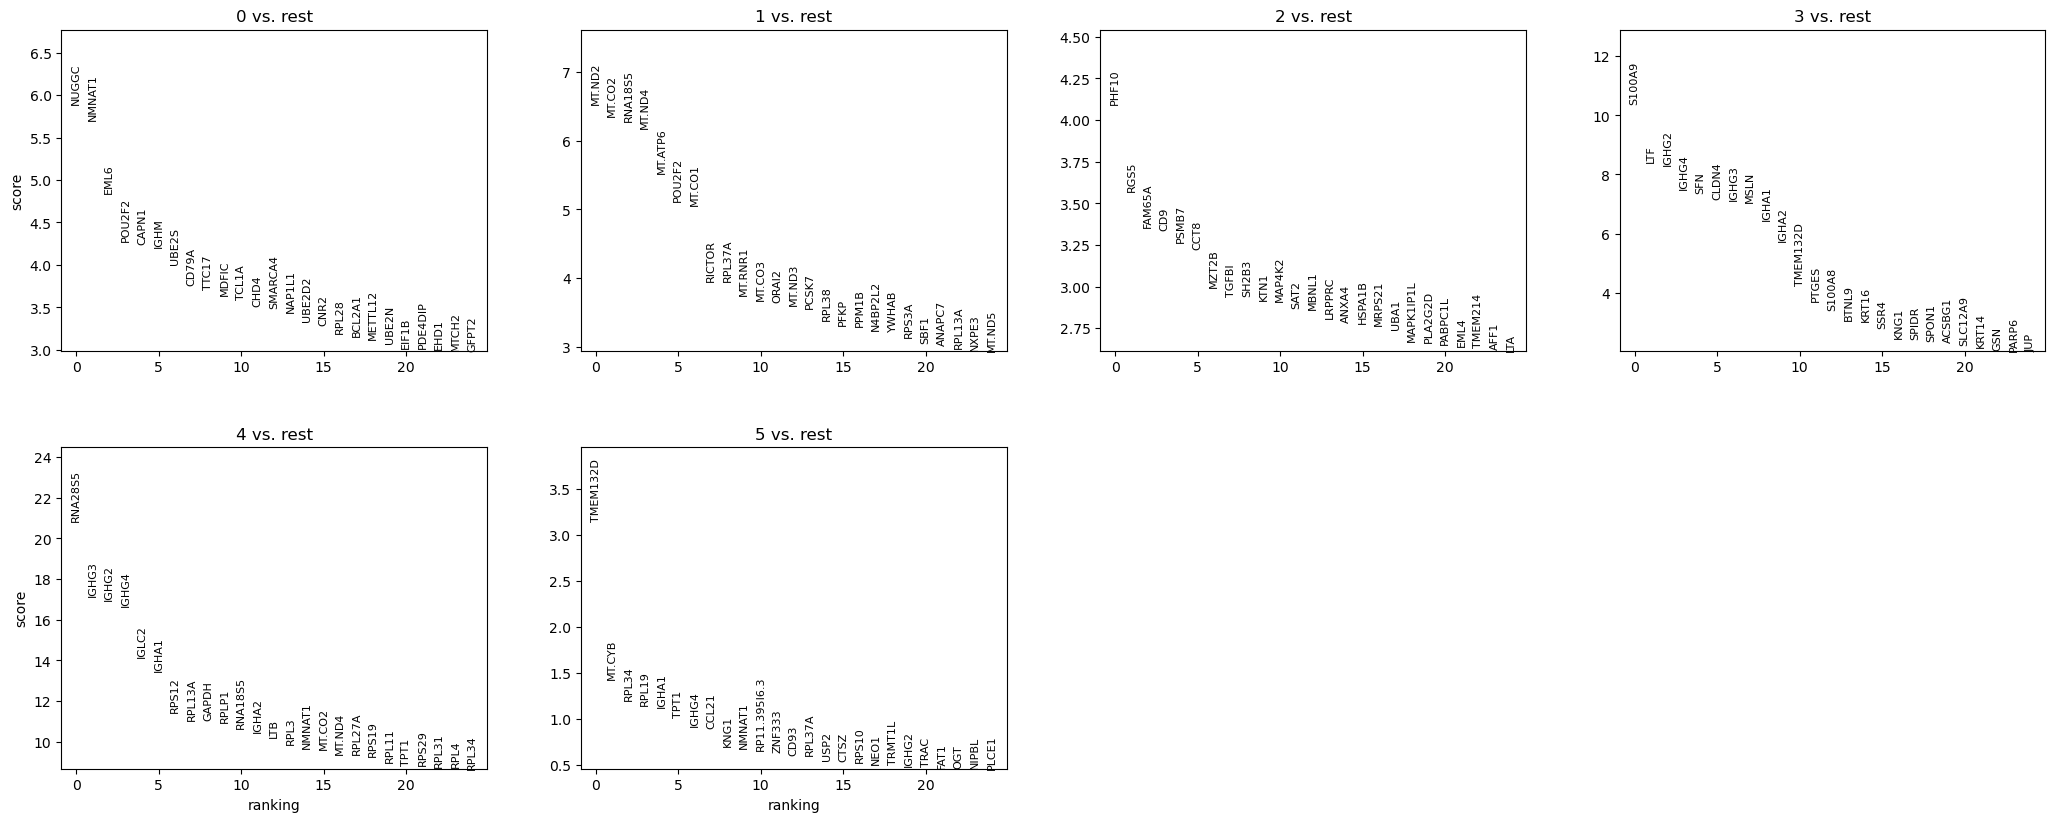

In [6]:
sc.tl.rank_genes_groups(rna_adata, 'leiden_eval', method='wilcoxon', key_added = "wilcoxon")
sc.pl.rank_genes_groups(rna_adata, n_genes=25, sharey=False, key="wilcoxon")

In [ ]:
rna_dotplot = sc.pl.rank_genes_groups_dotplot(rna_adata,
                                              n_genes=8, 
                                              values_to_plot="logfoldchanges",
                                              key="wilcoxon",
                                              groupby="leiden_eval",
                                              cmap = "RdBu_r",
                                              vcenter = 0,
                                              return_fig = True
                                              )

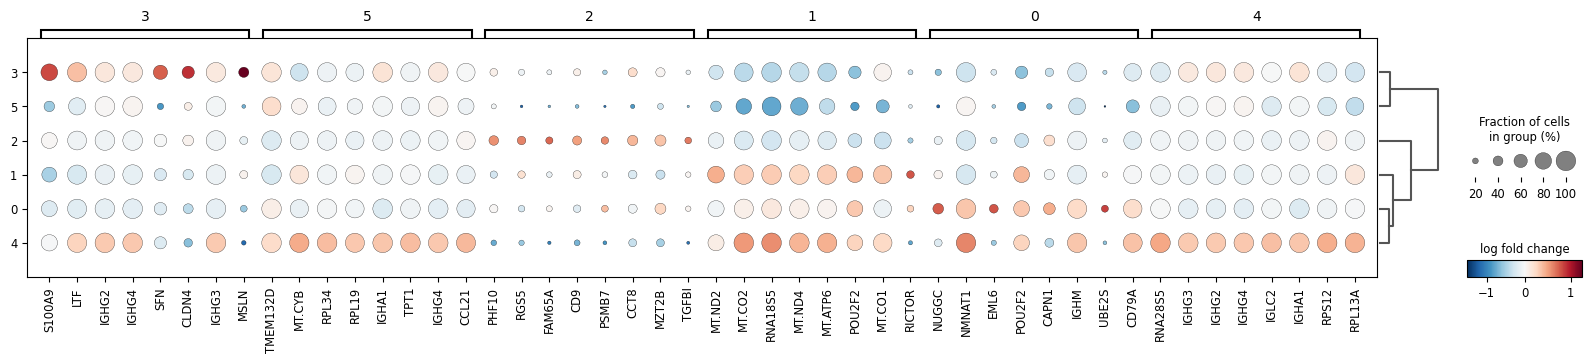

In [118]:
rna_dotplot.show()

In [120]:
rna_dotplot.fig.set_size_inches(w = 16, h = 6)
rna_dotplot.fig.savefig("../results/RNA_DE_dotplot.pdf", bbox_inches="tight")

Based on this, looks like:
- cluster 0 may be naive B cells?
- cluster 1 is maybe dying cells (lots of MT genes)
- cluster 2 maybe GCB/Dark-zone/plasmablast
- cluster 3 maybe tonsil epithelial cell (less likely to be DCs/monos)
- cluster 4 is memory B cells/plasma cells
- cluster 5 ?? may just be bad clustering resolution

## Protein

In [28]:
sc.pp.normalize_total(prot_adata) # tutorial said normalize_geometric but that function doesn't exist
sc.pp.log1p(prot_adata)

In [35]:
parsed_protein_names = [re.sub(pattern = "\.[ATGC]*$", repl = "", string = p) for p in prot_adata.var_names]
prot_adata.var["clean_names"] = parsed_protein_names

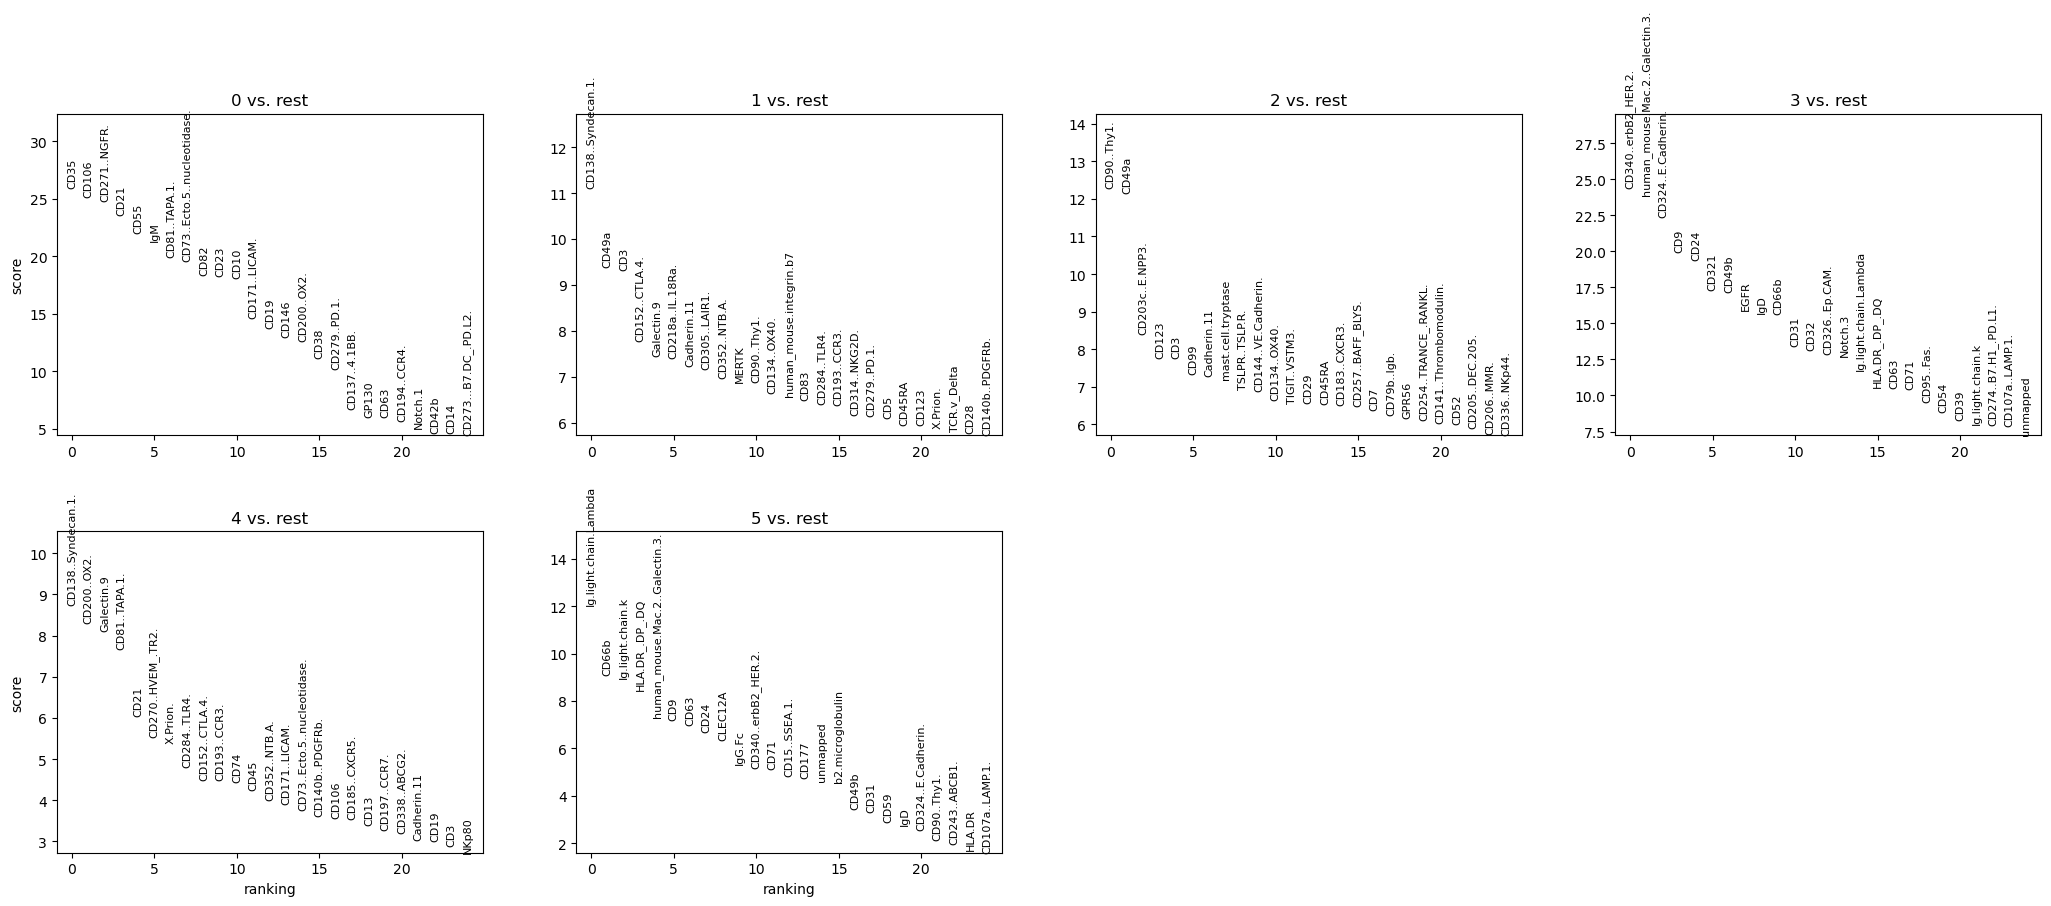

In [36]:
sc.tl.rank_genes_groups(prot_adata, 'leiden_eval', method='wilcoxon', key_added = "wilcoxon")
sc.pl.rank_genes_groups(prot_adata, n_genes=25, gene_symbols= 'clean_names', sharey=False, key="wilcoxon")

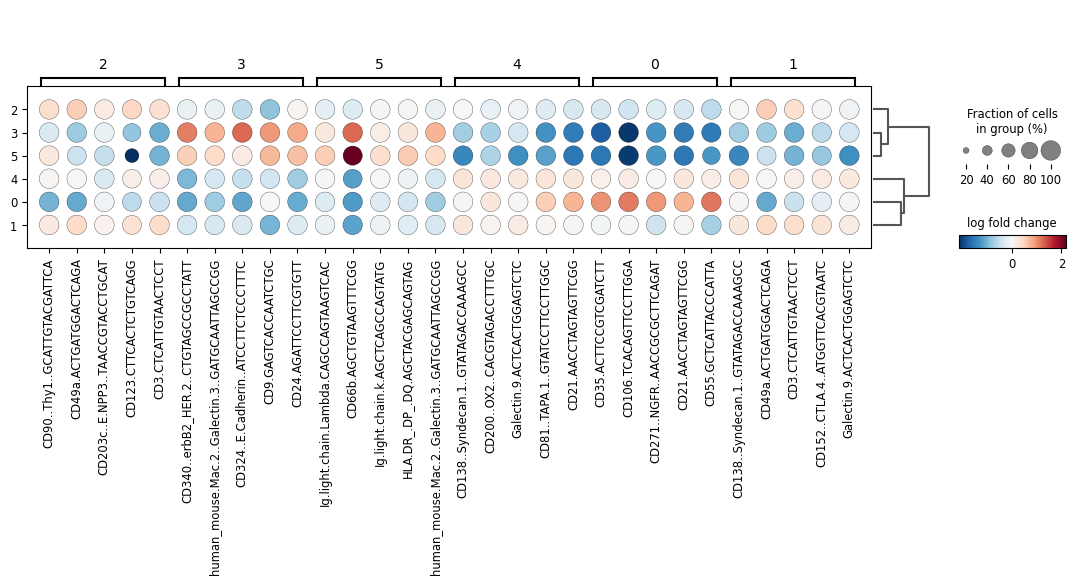

In [128]:
prot_dotplot = sc.pl.rank_genes_groups_dotplot(prot_adata,
                                               n_genes=5, 
                                               key="wilcoxon",
                                               groupby="leiden_eval",
                                             #   gene_symbols='clean_names',
                                               values_to_plot="logfoldchanges",
                                               cmap = "RdBu_r",
                                               vcenter = 0
                                               )

In [ ]:
prot_dotplot.savefig("../results/Protein_DE_dotplot.pdf", width = 10, height = 8)

In [102]:
prot_adata.var[prot_adata.var_names.str.contains("IL")]

,clean_names
CD127..IL.7Ra..GTGTGTTGTCCTATG,CD127..IL.7Ra.
CD124..IL.4Ra..CCGTCCTGATAGATG,CD124..IL.4Ra.
CD85j..ILT2..CCTTGTGAGGCTATG,CD85j..ILT2.
CD96..TACTILE..TGGCCTATAAATGGT,CD96..TACTILE.
CD122..IL.2Rb..TCATTTCCTCCGATT,CD122..IL.2Rb.
CD85g..ILT7..TGTCAGTTCCTATGA,CD85g..ILT7.
CD126..IL.6Ra..TGATGGGAGCTTATC,CD126..IL.6Ra.
CD218a..IL.18Ra..TTGTTGTATCCGATC,CD218a..IL.18Ra.
CD215..IL.15Ra..CATATTCCGCCGTAA,CD215..IL.15Ra.


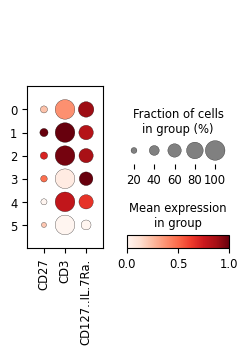

In [103]:
sc.pl.dotplot(prot_adata, use_raw=False, var_names = ['CD27', 'CD3', 'CD127..IL.7Ra.'], gene_symbols='clean_names', groupby='leiden_eval', standard_scale='var')